In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize
# from scipy import optimize


import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
# 1 0.138394
# 2 0.073868
# 4 2.994744726728921e-01

In [4]:
ov1 = np.loadtxt("ov_prop_temporal_L1_Nt192.dat2")
ov2 = np.loadtxt("ov_prop_temporal_L2_Nt192.dat2")
ov4 = np.loadtxt("ov_prop_temporal_L4_Nt192.dat2")

In [5]:
def Gt( t, nmax, T ):
    res = 0.0
    for n in range(nmax):
        res += (n+1.0) * ( np.exp( -(n+1.0)*t ) + np.exp( -(n+1.0)*(T-t) ) )
    res /= 4.0*np.pi
    return res

In [8]:
# T*np.arange(100)/100

In [9]:
T=12

ts=T*np.arange(100)/100
Gts = np.array([Gt( t, 10, T ) for t in ts])

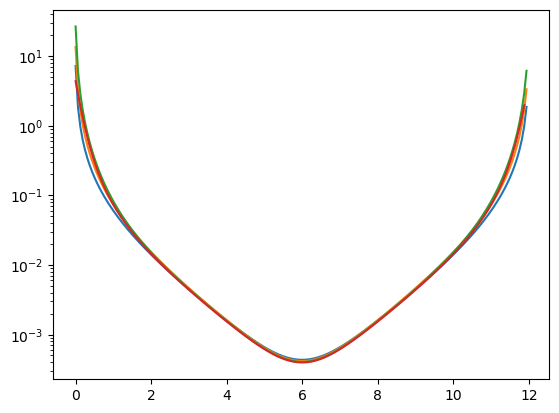

In [10]:
plt.plot( ov1.T[0][::2], ov1.T[1][::2] )
plt.plot( ov2.T[0][::2], ov2.T[1][::2] )
plt.plot( ov4.T[0][::2], ov4.T[1][::2] )

plt.plot( ts, Gts )

plt.yscale("log")

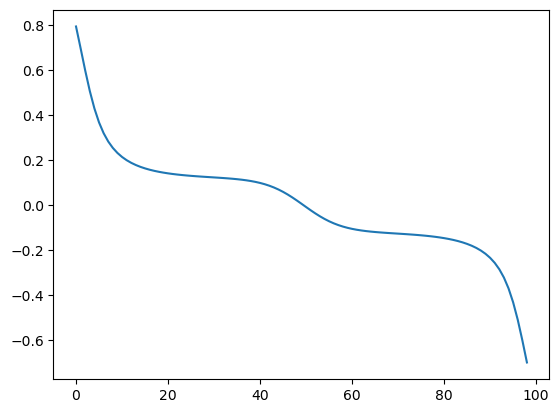

In [11]:
plt.plot(-np.log(Gts[1:]/Gts[:-1]))

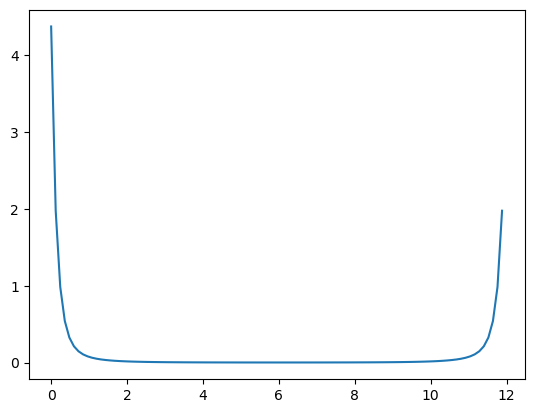

In [12]:
plt.plot( ts, Gts )



In [13]:
ts=T*np.arange(100)/100
Gts = np.array([Gt( t, 10, T ) for t in ts])

In [14]:
def fitter( t, z ):
    return np.log( z * Gt(t, nmax, T) )

In [15]:
for nmax in np.arange(1, 50):
    opt = sp.optimize.curve_fit( fitter, ov1.T[0][2::2], np.log(ov1.T[1][2::2]), full_output=True, p0=1 )
    diff = np.sum( opt[2]['fvec']**2 )
    print(diff, [opt[0][0], np.sqrt(opt[1][0,0]), nmax])

64.94987110432167 [1.4794025615507922, 0.06258659610883208, 1]
21.00652058329831 [1.1710805165010822, 0.02817541601949892, 2]
7.982031294809978 [1.071648947835626, 0.015893320445307172, 3]
3.8038754707065614 [1.0224817602330922, 0.010468277408058056, 4]
2.8558960338397377 [0.9932377637609604, 0.008811116397637358, 5]
3.2355731361482385 [0.9739199074218934, 0.009196135131697501, 6]
4.180686511288026 [0.9602589092325106, 0.010306673368538365, 7]
5.352830498293586 [0.9501232123785464, 0.011539255613811594, 8]
6.592268762242188 [0.9423298190222883, 0.01270065657350986, 9]
7.8214461957273524 [0.9361697248520173, 0.01374369534736751, 10]
9.002989553097596 [0.931192373780132, 0.014666880688754493, 11]
10.120003130849078 [0.9270979033379496, 0.015481764895645827, 12]
11.166284131724629 [0.9236791387036882, 0.01620240903170513, 13]
12.141250401668671 [0.920788434183221, 0.01684206213126209, 14]
13.047226417629396 [0.9183177927156216, 0.017412270486886743, 15]
13.887959611450333 [0.9161864416855

In [17]:
# 2.8558960338397377 [0.9932377637609604, 0.008811116397637358, 5]

In [18]:
ts=T*np.arange(100)/100
Gts = np.array([ 0.9932377637609604 * Gt( t, 5, T ) for t in ts])

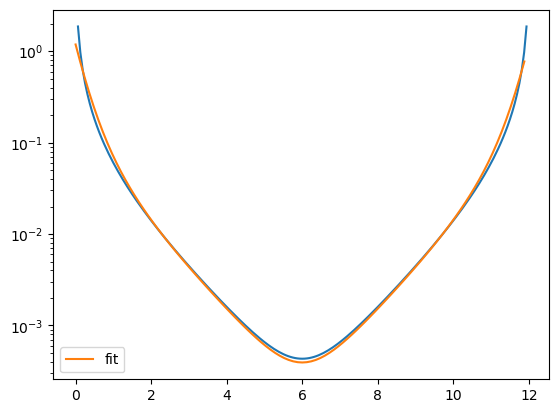

In [19]:
plt.plot( ov1.T[0][2::2], ov1.T[1][2::2] )
# plt.plot( ov2.T[0][::2], ov2.T[1][::2] )
# plt.plot( ov4.T[0][::2], ov4.T[1][::2] )

plt.plot( ts, Gts, label="fit" )

plt.legend()
plt.yscale("log")

In [20]:
for nmax in np.arange(1, 50):
    opt = sp.optimize.curve_fit( fitter, ov2.T[0][2::2], np.log(ov2.T[1][2::2]), full_output=True, p0=1 )
    diff = np.sum( opt[2]['fvec']**2 )
    print(diff, [opt[0][0], np.sqrt(opt[1][0,0]), nmax])

98.35285351497012 [1.6139209067241835, 0.08401936813524861, 1]
39.51515482061808 [1.277563916045667, 0.04215712392078658, 2]
18.327235997926127 [1.169091282904214, 0.02627262255330123, 3]
8.998868361906073 [1.1154534484475833, 0.01756488111706993, 4]
4.507985981596559 [1.0835503698524798, 0.012076605489073257, 5]
2.306303879882171 [1.062475989279985, 0.008469996486714215, 6]
1.2918414948159422 [1.047572831107865, 0.006250217377879176, 7]
0.9297647779753537 [1.0365155205574572, 0.0052464892830976105, 8]
0.9386642676597226 [1.0280134937995746, 0.005228299345313582, 9]
1.161531161048958 [1.0212932779659345, 0.0057779318753765655, 10]
1.5068926906560332 [1.0158633483072979, 0.006546105021601654, 11]
1.919742932707066 [1.0113965769104891, 0.0073561324513568135, 12]
2.366263471487839 [1.0076669541548116, 0.0081368270068133, 13]
2.8253780583953474 [1.0045134049996416, 0.008863314309058264, 14]
3.2838880833409556 [1.0018181139713236, 0.009529911268573834, 15]
3.7335730039955726 [0.999492965594

In [24]:
# 0.9297647779753537 [1.0365155205574572, 0.0052464892830976105, 8]

In [25]:
ts=T*np.arange(100)/100
Gts = np.array([ 1.0365155205574572 * Gt( t, 8, T ) for t in ts])

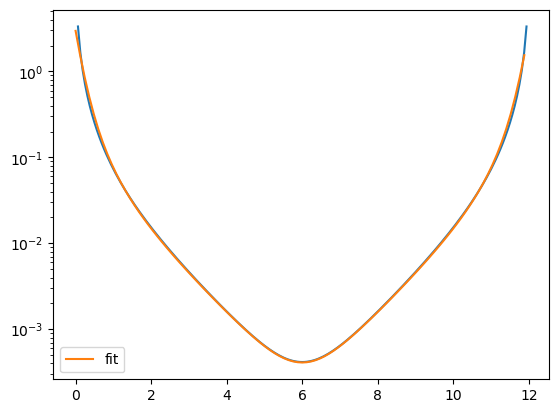

In [26]:
plt.plot( ov2.T[0][2::2], ov2.T[1][2::2] )
# plt.plot( ov2.T[0][::2], ov2.T[1][::2] )
# plt.plot( ov4.T[0][::2], ov4.T[1][::2] )

plt.plot( ts, Gts, label="fit" )

plt.legend()
plt.yscale("log")

In [27]:
np.sqrt(opt[1][0])

array([0.01685022])

In [28]:
for nmax in np.arange(1, 50):
    opt = sp.optimize.curve_fit( fitter, ov4.T[0][2::2], np.log(ov4.T[1][2::2]), full_output=True, absolute_sigma=True, p0=1 )
    diff = np.sum( opt[2]['fvec']**2 )
    print(diff, [opt[0][0], np.sqrt(opt[1][0,0]), nmax])

139.83152445052625 [1.6751024932949368, 0.12120484021007101, 1]
66.8083859344618 [1.3259946591520677, 0.09594559203062643, 2]
37.29373823235468 [1.2134099736627224, 0.0877992649876594, 3]
22.519862350426617 [1.1577387962135612, 0.08377104062937403, 4]
14.203999622536049 [1.1246263165509698, 0.0813734450849328, 5]
9.177941521712906 [1.1027530346969876, 0.07979160654078514, 6]
5.999483429533633 [1.0872849180562822, 0.07867274433141076, 7]
3.9315670488050944 [1.075808439148255, 0.07784251485923532, 8]
2.565089939449008 [1.0669841119867556, 0.0772041052829801, 9]
1.6584874675251253 [1.0600091420129718, 0.07669946846402248, 10]
1.0621037696562485 [1.0543733708094731, 0.07629171052193622, 11]
0.6796075751906316 [1.0497372722805287, 0.07595627441473118, 12]
0.4470365703053582 [1.0458662626474389, 0.07567619163124402, 13]
0.32082213063600334 [1.0425931662556613, 0.07543936733253094, 14]
0.27065095517473203 [1.039795700453091, 0.07523695613424061, 15]
0.27505579374244166 [1.0373824084309977, 0.

In [29]:
# 0.27065095517473203 [1.039795700453091, 0.07523695613424061, 15]

In [30]:
ts=T*np.arange(100)/100
Gts = np.array([ 1.039795700453091* Gt( t, 15, T ) for t in ts])

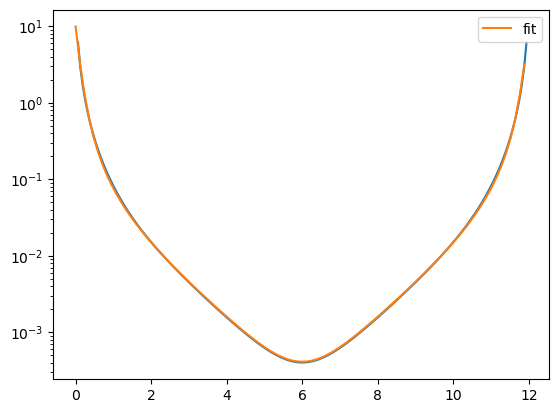

In [31]:
plt.plot( ov4.T[0][2::2], ov4.T[1][2::2] )
# plt.plot( ov2.T[0][::2], ov2.T[1][::2] )
# plt.plot( ov4.T[0][::2], ov4.T[1][::2] )

plt.plot( ts, Gts, label="fit" )

plt.legend()
plt.yscale("log")